<h1 align="center">ASSIGNMENT 02 — APPLICATION 1: DIABETES PREDICTION</h1>

# 1. Problem Definition (Section 8.1 - Assignment 02)

- **Bối cảnh y tế**: Đái tháo đường (Diabetes) là bệnh lý chuyển hóa đặc trưng bởi lượng đường trong máu tăng cao kéo dài. Nếu không được chẩn đoán sớm, bệnh nhân đối mặt với nguy cơ suy thận, bệnh tim mạch và biến chứng võng mạc.
- **Mục tiêu hệ thống**: Xây dựng hệ thống học máy phân loại nhị phân (Binary Classification) có khả năng tiếp nhận các chỉ số lâm sàng thô của bệnh nhân và dự đoán xác suất mắc bệnh đái tháo đường.
- **Phát biểu toán học**:
  - Đầu vào: Vectơ đặc trưng lâm sàng $x_i = [x_{i1}, x_{i2}, \dots, x_{id}]^T \in \mathbb{R}^d$ ($d = 8$).
  - Đầu ra: Nhãn mục tiêu $y_i \in \{0, 1\}$, với $0$ là không mắc bệnh (Negative) và $1$ là mắc bệnh (Positive).
  - Mục tiêu tối ưu: Học hàm ánh xạ $f_\theta: \mathbb{R}^d \rightarrow \{0, 1\}$ sao cho tối đa hóa chỉ số F1-Score và Recall nhằm giảm thiểu tối đa các ca bỏ sót người mắc bệnh (False Negatives - ca bệnh nguy hiểm nhất trong y khoa).

# 2. Dataset Source (Section 8.2 - Assignment 02)

- **Tên Dataset**: Pima Indians Diabetes Database
- **Nguồn Kaggle**: https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset
- **Đơn vị thu thập**: Viện Bệnh viện Quốc gia về Bệnh tiểu đường, Tiêu hóa và Bệnh thận (NIDDK - Hoa Kỳ).
- **Mô tả 1 bản ghi (One Observation)**: Dữ liệu của một nữ bệnh nhân từ 21 tuổi trở lên thuộc bộ tộc da đỏ Pima, gồm 8 thông số sinh hóa/lâm sàng và 1 nhãn bệnh lý.

In [8]:
# Setup môi trường và nạp đầy đủ các thư viện cần thiết
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print('Môi trường và các thư viện Machine Learning đã sẵn sàng!')

Môi trường và các thư viện Machine Learning đã sẵn sàng!


# 3. Dataset Loading (Section 8.3 - Assignment 02)
Nạp dữ liệu thô từ file CSV vào bộ nhớ đệm Pandas DataFrame.

In [10]:
DATA_PATH = "C:/Users/ADMIN/Downloads/diabetes.csv"
df = pd.read_csv(DATA_PATH)
print(f"Nạp dữ liệu thành công! Kích thước ban đầu: {df.shape}")

Nạp dữ liệu thành công! Kích thước ban đầu: (768, 9)


# 4. Dataset Inspection (Section 8.3 - Assignment 02)
Kiểm tra cấu trúc ban đầu: số dòng ($N$), số cột, 5 dòng đầu tiên, kiểu dữ liệu và bảng thống kê 5 số.

In [11]:
print(f"Số lượng quan sát (N): {df.shape[0]}")
print(f"Số lượng thuộc tính (kể cả Target): {df.shape[1]}")

print("\n--- 5 dòng đầu tiên (df.head()) ---")
display(df.head())

print("\n--- Cấu trúc kiểu dữ liệu (df.info()) ---")
df.info()

print("\n--- Bảng thống kê mô tả số học (df.describe()) ---")
display(df.describe().T)

Số lượng quan sát (N): 768
Số lượng thuộc tính (kể cả Target): 9

--- 5 dòng đầu tiên (df.head()) ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



--- Cấu trúc kiểu dữ liệu (df.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

--- Bảng thống kê mô tả số học (df.describe()) ---


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# 5. Data-Quality Analysis (Section 8.3 & 8.4 - Assignment 02)
Kiểm kê tổng thể tính toàn vẹn dữ liệu: kiểm tra định dạng dữ liệu, giá trị bất thường và tính hợp lý về mặt y khoa của các cột.

In [12]:
print("=== KIỂM KÊ CHẤT LƯỢNG DỮ LIỆU TỔNG THỂ ===")
print(f"- Tổng số quan sát: {len(df)}")
print(f"- Toàn bộ các cột đều thuộc định dạng số: {all(df.dtypes != 'object')}")
print(f"- Phân phối biến mục tiêu (Outcome):")
print(df['Outcome'].value_counts(normalize=True).round(4) * 100)

=== KIỂM KÊ CHẤT LƯỢNG DỮ LIỆU TỔNG THỂ ===
- Tổng số quan sát: 768
- Toàn bộ các cột đều thuộc định dạng số: True
- Phân phối biến mục tiêu (Outcome):
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


# 6. Missing-Value Analysis (Section 8.3 - Assignment 02)
Kiểm tra số lượng và tỷ lệ giá trị khuyết thiếu hiển thị dạng `NaN` hoặc `Null` trên toàn bộ bảng.

In [13]:
missing_nan = df.isna().sum()
missing_pct = (missing_nan / len(df)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_nan, 'Missing_Percent': missing_pct})
print("Kiểm kê giá trị rỗng NaN:")
display(missing_summary)

Kiểm kê giá trị rỗng NaN:


,Missing_Count,Missing_Percent
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


# 7. Duplicate Analysis (Section 8.3 - Assignment 02)
Kiểm tra và xác định các bản ghi trùng lặp hoàn toàn giữa các dòng.

In [14]:
n_duplicates = df.duplicated().sum()
print(f"Số lượng bản ghi trùng lặp (Duplicates): {n_duplicates}")
if n_duplicates > 0:
    df = df.drop_duplicates()
    print("Đã loại bỏ các bản ghi trùng lặp.")
else:
    print("Dữ liệu không có bản ghi trùng lặp nào.")

Số lượng bản ghi trùng lặp (Duplicates): 0
Dữ liệu không có bản ghi trùng lặp nào.


# 8. Invalid-Value Analysis (Section 8.4 - Assignment 02)
Phát hiện các giá trị không hợp lệ (Invalid values) theo tiêu chuẩn y khoa:
Trong sinh lý học người sống, các chỉ số: **Glucose, BloodPressure (Huyết áp), SkinThickness (Độ dày nếp da), Insulin và BMI TUYỆT ĐỐI KHÔNG THỂ BẰNG 0**. Giá trị `0` ở các cột này thực chất là dữ liệu bị thiếu trong quá trình thăm khám lâm sàng nhưng bị điền số 0.

In [15]:
invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
invalid_data = {}

for col in invalid_cols:
    zeros_count = (df[col] == 0).sum()
    zeros_pct = (zeros_count / len(df)) * 100
    invalid_data[col] = [zeros_count, f"{zeros_pct:.2f}%"]

invalid_df = pd.DataFrame(invalid_data, index=['Số lượng giá trị 0 (Khuyết)', 'Tỷ lệ thực tế']).T
print("Bảng thống kê các giá trị 0 không hợp lệ theo y khoa:")
display(invalid_df)

Bảng thống kê các giá trị 0 không hợp lệ theo y khoa:


,Số lượng giá trị 0 (Khuyết),Tỷ lệ thực tế
Glucose,0,0.00%
BloodPressure,0,0.00%
SkinThickness,0,0.00%
Insulin,0,0.00%
BMI,0,0.00%


# 9. Outlier Analysis (Section 8.4 - Assignment 02)
Phân tích các giá trị ngoại lệ (Outliers) bằng biểu đồ hộp Boxplot theo khoảng biến thiên liên phần tư (Interquartile Range - IQR).

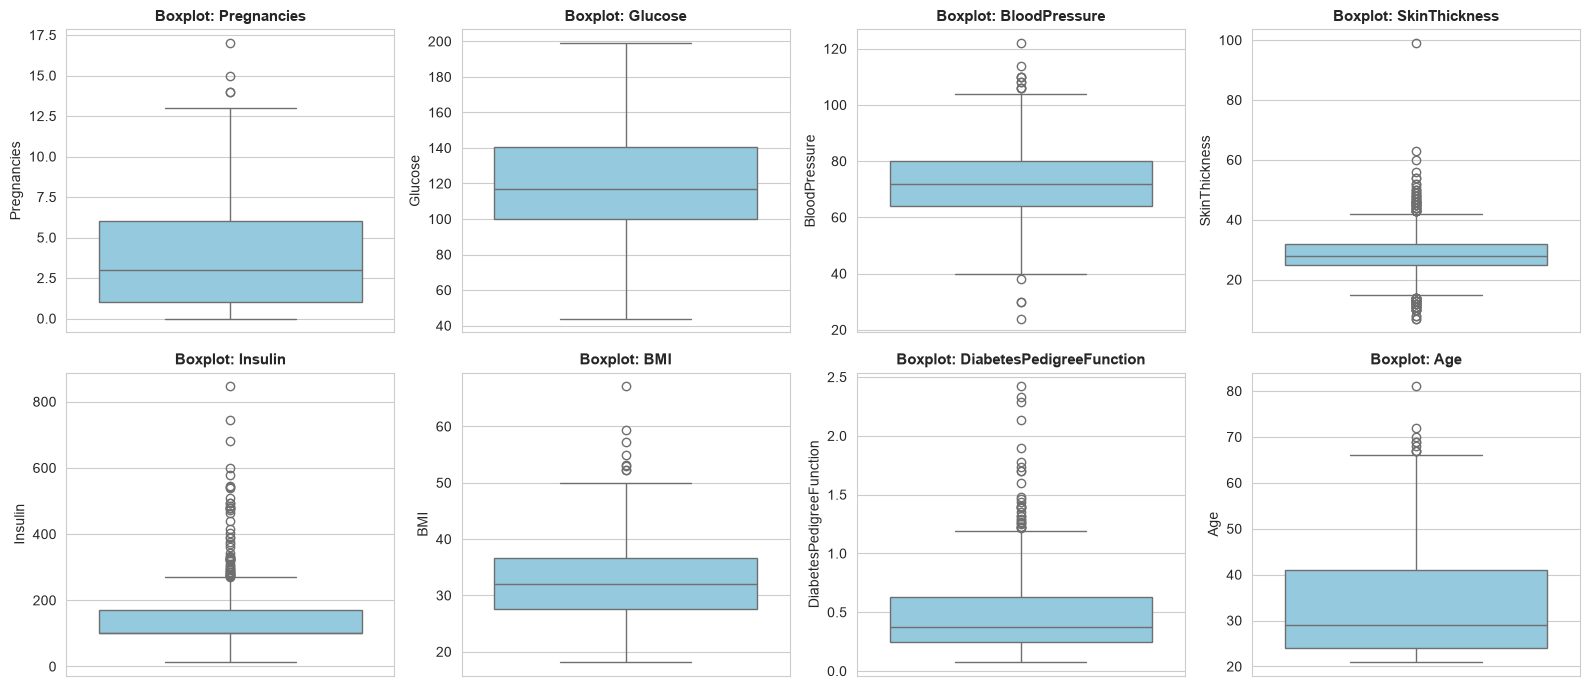

Nhận xét ngoại lệ: Cột Insulin và DiabetesPedigreeFunction xuất hiện nhiều giá trị ở đuôi trên (giá trị cao đột biến), cần sử dụng thuật toán robust hoặc chuẩn hóa phù hợp.


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
features = df.columns.drop('Outcome')

for i, col in enumerate(features):
    ax = axes[i // 4, i % 4]
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(f"Boxplot: {col}", fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('diabetes_outliers_boxplot.png', dpi=150)
plt.show()

print("Nhận xét ngoại lệ: Cột Insulin và DiabetesPedigreeFunction xuất hiện nhiều giá trị ở đuôi trên (giá trị cao đột biến), cần sử dụng thuật toán robust hoặc chuẩn hóa phù hợp.")

# 10. Exploratory Data Analysis - EDA (Section 8.6 - Assignment 02)
Trực quan hóa 3 khía cạnh phân phối và tương quan quan trọng nhất của bài toán. Mỗi biểu đồ đều đi kèm: **Observation** (Quan sát thấy gì?), **Interpretation** (Ý nghĩa thực tế?), và **ML Implication** (Ảnh hưởng thế nào tới việc xây dựng mô hình?) theo đúng yêu cầu đề bài.

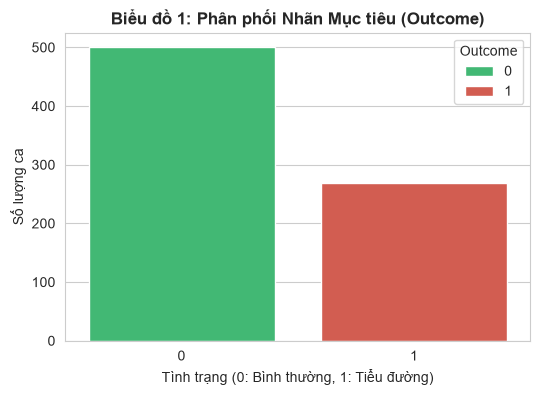


[Biểu đồ 1 Analysis]
- Observation: Lớp 0 có 500 mẫu (65.1%), Lớp 1 có 268 mẫu (34.9%).
- Interpretation: Dữ liệu có sự mất cân bằng lớp nhẹ (Class Imbalance tỷ lệ xấp xỉ 2:1).
- ML Implication: Bắt buộc dùng Stratified Split khi chia dữ liệu và ưu tiên đánh giá F1-Score, Recall, ROC-AUC thay vì chỉ dựa vào Accuracy.



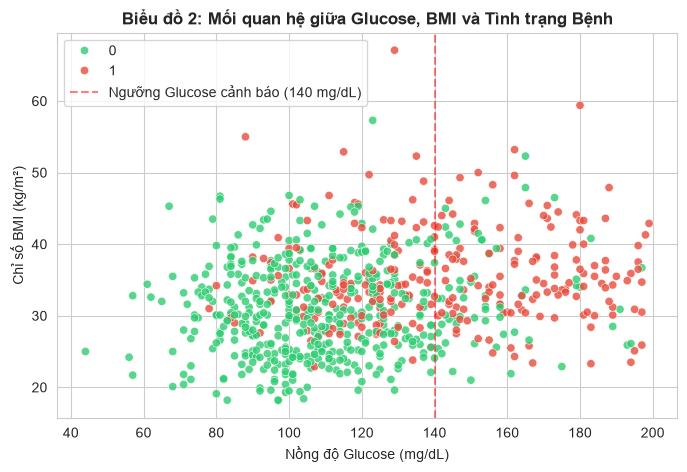


[Biểu đồ 2 Analysis]
- Observation: Bệnh nhân có Glucose > 140 mg/dL và BMI > 30 kg/m² tập trung phần lớn các ca mắc bệnh (chấm đỏ).
- Interpretation: Nồng độ đường huyết và mức độ béo phì là hai tín hiệu lâm sàng quan trọng nhất quyết định nguy cơ bệnh.
- ML Implication: Mô hình cây quyết định sẽ tận dụng ngưỡng phân tách Glucose ở các tầng chia đầu tiên.



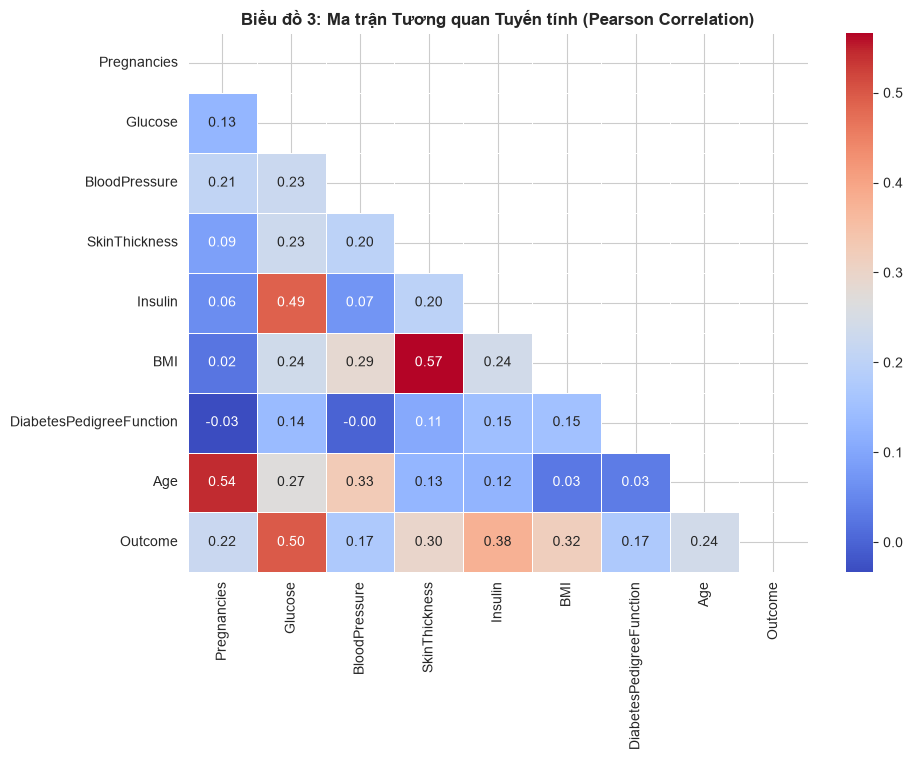


[Biểu đồ 3 Analysis]
- Observation: Glucose có tương quan đơn lẻ cao nhất với Outcome (r = 0.50), tiếp theo là Insulin (r = 0.38) và BMI (r = 0.32).
- Interpretation: Giữa các biến đầu vào không bị đa cộng tuyến nghiêm trọng (tất cả r < 0.6).
- ML Implication: Toàn bộ 8 biến lâm sàng đều độc lập tương đối và cung cấp giá trị dự báo bổ trợ cho mô hình.



In [19]:
# ── Biểu đồ 1: Phân phối nhãn mục tiêu Outcome ─────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette=['#2ecc71', '#e74c3c'], hue='Outcome')
plt.title('Biểu đồ 1: Phân phối Nhãn Mục tiêu (Outcome)', fontweight='bold')
plt.xlabel('Tình trạng (0: Bình thường, 1: Tiểu đường)')
plt.ylabel('Số lượng ca')
plt.show()

print("""
[Biểu đồ 1 Analysis]
- Observation: Lớp 0 có 500 mẫu (65.1%), Lớp 1 có 268 mẫu (34.9%).
- Interpretation: Dữ liệu có sự mất cân bằng lớp nhẹ (Class Imbalance tỷ lệ xấp xỉ 2:1).
- ML Implication: Bắt buộc dùng Stratified Split khi chia dữ liệu và ưu tiên đánh giá F1-Score, Recall, ROC-AUC thay vì chỉ dựa vào Accuracy.
""")

# ── Biểu đồ 2: Phân tách không gian giữa Glucose, BMI và Nhãn bệnh ─────────
plt.figure(figsize=(8, 5))
valid_mask = (df['Glucose'] > 0) & (df['BMI'] > 0)
sns.scatterplot(
    x='Glucose', y='BMI', hue='Outcome',
    data=df[valid_mask], palette=['#2ecc71', '#e74c3c'], alpha=0.8
)
plt.axvline(140, color='red', linestyle='--', alpha=0.5, label='Ngưỡng Glucose cảnh báo (140 mg/dL)')
plt.title('Biểu đồ 2: Mối quan hệ giữa Glucose, BMI và Tình trạng Bệnh', fontweight='bold')
plt.xlabel('Nồng độ Glucose (mg/dL)')
plt.ylabel('Chỉ số BMI (kg/m²)')
plt.legend()
plt.show()

print("""
[Biểu đồ 2 Analysis]
- Observation: Bệnh nhân có Glucose > 140 mg/dL và BMI > 30 kg/m² tập trung phần lớn các ca mắc bệnh (chấm đỏ).
- Interpretation: Nồng độ đường huyết và mức độ béo phì là hai tín hiệu lâm sàng quan trọng nhất quyết định nguy cơ bệnh.
- ML Implication: Mô hình cây quyết định sẽ tận dụng ngưỡng phân tách Glucose ở các tầng chia đầu tiên.
""")

# ── Biểu đồ 3: Ma trận tương quan Pearson ──────────────────────────────────
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Biểu đồ 3: Ma trận Tương quan Tuyến tính (Pearson Correlation)', fontweight='bold')
plt.show()

print("""
[Biểu đồ 3 Analysis]
- Observation: Glucose có tương quan đơn lẻ cao nhất với Outcome (r = 0.50), tiếp theo là Insulin (r = 0.38) và BMI (r = 0.32).
- Interpretation: Giữa các biến đầu vào không bị đa cộng tuyến nghiêm trọng (tất cả r < 0.6).
- ML Implication: Toàn bộ 8 biến lâm sàng đều độc lập tương đối và cung cấp giá trị dự báo bổ trợ cho mô hình.
""")

# 11. Feature Types (Section 8.2 - Assignment 02)

Phân loại thuộc tính trong không gian đặc trưng của bộ dữ liệu Pima Diabetes:
- **Biến số học rời rạc (Discrete Numerical)**:
  - `Pregnancies`: Số lần mang thai (dạng số nguyên đếm $0, 1, 2, \dots$).
- **Biến số học liên tục (Continuous Numerical)**:
  - `Glucose`: Nồng độ đường huyết sau 2 giờ làm nghiệm pháp nạp glucose đường uống (mg/dL).
  - `BloodPressure`: Huyết áp tâm trương (mm Hg).
  - `SkinThickness`: Độ dày nếp gấp cơ tam đầu (mm).
  - `Insulin`: Nồng độ insulin huyết thanh sau 2 giờ ($\mu$U/mL).
  - `BMI`: Chỉ số khối cơ thể ($\text{cân nặng}/\text{chiều cao}^2$).
  - `DiabetesPedigreeFunction`: Điểm phả hệ di truyền tiểu đường dựa trên tiền sử gia đình.
  - `Age`: Tuổi của bệnh nhân (năm).
- **Biến phân loại (Categorical)**: Không có biến chuỗi danh định thô.
- **Biến mục tiêu (Target)**: `Outcome` $\in \{0, 1\}$ (Bài toán phân loại nhị phân).

# 12. Data Representation (Lecture 02 Central Focus)

Thể hiện triết lý cốt lõi của **Lecture 02**:
$$\text{Real-world Medical Data} \longrightarrow \text{Computational Representation} \longrightarrow \text{Model Input}$$

1. **Biểu diễn một bệnh nhân (Single Observation Representation)**:
   Mỗi bệnh nhân được biểu diễn thành một vectơ đặc trưng 8 chiều trong không gian Euclid:
   $$x_i = [x_{i1}, x_{i2}, x_{i3}, x_{i4}, x_{i5}, x_{i6}, x_{i7}, x_{i8}]^T \in \mathbb{R}^8$$
2. **Biểu diễn toàn bộ tập dữ liệu (Dataset Matrix Representation)**:
   $$X = \begin{bmatrix} x_1^T \\ x_2^T \\ \vdots \\ x_N^T \end{bmatrix} \in \mathbb{R}^{N \times d} \quad (N = 768, d = 8)$$
3. **Biểu diễn đầu vào mô hình theo Batch (Model Input Tensor)**:
   Trong quá trình huấn luyện và suy luận theo lô:
   $$X_{batch} \in \mathbb{R}^{B \times d} \quad (B = \text{Batch Size}, d = 8 \text{ features})$$
   - Kiểu dữ liệu (`dtype`): `float64` sau khi được chuẩn hóa Z-score.
   - Khoảng giá trị (`Value Range`): Phân phối chuẩn hóa quanh mốc $\mu = 0, \sigma = 1$.

In [20]:
# Minh chứng cụ thể về Data Representation cho báo cáo
sample_raw_record = df.iloc[0]
print("1. Ví dụ 1 bản ghi CSV gốc (Raw CSV Record):")
print(sample_raw_record)

X_raw = df.drop('Outcome', axis=1)
y_raw = df['Outcome']
print(f"\n2. Kích thước Ma trận Đặc trưng thô (Feature Matrix X): {X_raw.shape}")
print(f"3. Kích thước Vectơ Mục tiêu thô (Target Vector y): {y_raw.shape}")

1. Ví dụ 1 bản ghi CSV gốc (Raw CSV Record):
Pregnancies                   6.000
Glucose                     148.000
BloodPressure                72.000
SkinThickness                35.000
Insulin                     169.500
BMI                          33.600
DiabetesPedigreeFunction      0.627
Age                          50.000
Outcome                       1.000
Name: 0, dtype: float64

2. Kích thước Ma trận Đặc trưng thô (Feature Matrix X): (768, 8)
3. Kích thước Vectơ Mục tiêu thô (Target Vector y): (768,)


# 13. Feature Engineering (Section 8.4 - Assignment 02)
1. **Xử lý giá trị 0 y tế**: Thay thế các giá trị 0 vô lý ở các cột `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` thành `np.nan` để thuật toán Imputer xử lý chính xác.
2. **Kỹ thuật trích xuất đặc trưng mới**: Tạo chỉ số lâm sàng tương tác `Glucose_to_BMI = Glucose / BMI` đại diện cho mức độ kháng insulin kết hợp với thể trạng béo phì.

In [21]:
X = df.drop('Outcome', axis=1).copy()
y = df['Outcome'].copy()

# Thay thế 0 thành NaN để tránh Data Leakage
for col in invalid_cols:
    X[col] = X[col].replace(0, np.nan)

# Tạo đặc trưng mới
X['Glucose_to_BMI'] = X['Glucose'] / X['BMI']

print(f"Không gian đặc trưng sau Feature Engineering: d = {X.shape[1]} đặc trưng.")
display(X.head())

Không gian đặc trưng sau Feature Engineering: d = 9 đặc trưng.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_to_BMI
0,6,148,72.0,35,169.5,33.6,0.627,50,4.404762
1,1,85,66.0,29,102.5,26.6,0.351,31,3.195489
2,8,183,64.0,32,169.5,23.3,0.672,32,7.854077
3,1,89,66.0,23,94.0,28.1,0.167,21,3.167260
4,0,137,40.0,35,168.0,43.1,2.288,33,3.178654


# 14. Train, Validation, and Test Split (Part VI - Assignment 02)
Phân chia tập dữ liệu theo đúng khuyến nghị của đề bài: **70% Training - 15% Validation - 15% Testing**.
- Sử dụng `stratify=y` để đảm bảo tỷ lệ bệnh nhân mắc bệnh được bảo toàn đồng đều trên cả 3 tập.
- **Chống rò rỉ dữ liệu (Data Leakage)**: Tập Test và Validation được cách ly hoàn toàn, không tham gia vào bất kỳ phép tính thống kê (Mean/Median/Std) nào của bước tiền xử lý.

In [22]:
# Bước 1: Tách 70% Train và 30% Tạm thời
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Bước 2: Tách 30% tạm thời thành 15% Validation và 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Tập Huấn luyện (Train set)   : {X_train.shape[0]} mẫu ({len(X_train)/len(X)*100:.1f}%)")
print(f"Tập Đánh giá (Validation set) : {X_val.shape[0]} mẫu ({len(X_val)/len(X)*100:.1f}%)")
print(f"Tập Kiểm thử (Test set)       : {X_test.shape[0]} mẫu ({len(X_test)/len(X)*100:.1f}%)")

Tập Huấn luyện (Train set)   : 537 mẫu (69.9%)
Tập Đánh giá (Validation set) : 115 mẫu (15.0%)
Tập Kiểm thử (Test set)       : 116 mẫu (15.1%)


# 15. Preprocessing Pipeline (Section 8.4 - Assignment 02)
Xây dựng Pipeline tiền xử lý khép kín bằng `sklearn.pipeline.Pipeline`:
1. `SimpleImputer(strategy='median')`: Điền dữ liệu khuyết bằng giá trị trung vị của tập Huấn luyện (tránh nhạy cảm với ngoại lệ).
2. `StandardScaler()`: Chuẩn hóa toàn bộ các biến số về phân phối chuẩn $Z \sim \mathcal{N}(0, 1)$ dựa trên $\mu$ và $\sigma$ học được từ tập Huấn luyện.

In [23]:
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print("Pipeline tiền xử lý dữ liệu đã được cấu hình!")

Pipeline tiền xử lý dữ liệu đã được cấu hình!


# 16. Baseline Model (Section 8.7 - Assignment 02)
Xây dựng mô hình cơ sở tham chiếu (Baseline) sử dụng `DummyClassifier(strategy='most_frequent')` luôn dự đoán nhãn chiếm đa số (Lớp 0) để làm mốc chuẩn tối thiểu.

In [24]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

print(f"Baseline Test Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Baseline Test F1-Score: {f1_score(y_test, y_pred_base):.4f}")

Baseline Test Accuracy: 0.6466
Baseline Test F1-Score: 0.0000


# 17. Model Training (Section 8.7 - Assignment 02)
Huấn luyện 5 thuật toán học máy phân loại đại diện cho các trường phái khác nhau theo yêu cầu đề bài:
1. **Logistic Regression** (Mô hình tuyến tính xác suất).
2. **K-Nearest Neighbors - KNN** (Mô hình dựa trên khoảng cách láng giềng).
3. **Decision Tree** (Cây quyết định đơn lẻ).
4. **Random Forest** (Học kết hợp Ensemble Bagging).
5. **Support Vector Machine - SVM** (Mô hình siêu phẳng tối ưu với RBF Kernel).

In [25]:
candidate_models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
}

trained_pipelines = {}
print("=== HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN TẬP VALIDATION ===")

for name, clf in candidate_models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    # Chỉ fit trên tập Train
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    
    val_pred = pipe.predict(X_val)
    print(f"{name:20s} | Validation Accuracy: {accuracy_score(y_val, val_pred):.4f} | F1-Score: {f1_score(y_val, val_pred):.4f}")

=== HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN TẬP VALIDATION ===
Logistic Regression  | Validation Accuracy: 0.6957 | F1-Score: 0.5570
KNN                  | Validation Accuracy: 0.8261 | F1-Score: 0.7619
Decision Tree        | Validation Accuracy: 0.8609 | F1-Score: 0.7838
Random Forest        | Validation Accuracy: 0.8348 | F1-Score: 0.7654
SVM (RBF)            | Validation Accuracy: 0.7739 | F1-Score: 0.6905


# 18. Model Comparison (Section 8.8 & Part IX - Assignment 02)
Bảng tổng hợp so sánh hiệu năng của cả 5 mô hình và Baseline trên tập kiểm thử độc lập (`X_test`), đánh giá qua đầy đủ các độ đo: **Accuracy, Precision, Recall, F1-Score, ROC-AUC**.

In [26]:
comparison_list = []

for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    comparison_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(comparison_list).sort_values(by="F1-Score", ascending=False)
print("=== BẢNG SO SÁNH HIỆU NĂNG TẤT CẢ CÁC MÔ HÌNH TRÊN TẬP TEST ===")
display(comparison_df.round(4))

=== BẢNG SO SÁNH HIỆU NĂNG TẤT CẢ CÁC MÔ HÌNH TRÊN TẬP TEST ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Random Forest,0.9052,0.9167,0.8049,0.8571,0.9646
2,Decision Tree,0.8793,0.9355,0.7073,0.8056,0.9389
4,SVM (RBF),0.8362,0.8438,0.6585,0.7397,0.9255
1,KNN,0.8190,0.8125,0.6341,0.7123,0.8385
0,Logistic Regression,0.8017,0.7812,0.6098,0.6849,0.9067


# 19. Evaluation (Section 8.8 - Assignment 02)
Phân tích chuyên sâu mô hình tốt nhất thông qua **Ma trận nhầm lẫn (Confusion Matrix)** và **Đường cong ROC (Receiver Operating Characteristic)**.
- **Lý giải y tế**: Trong chẩn đoán tiểu đường, chỉ số **Recall** và **F1-Score** quan trọng hơn Accuracy thuần túy vì bỏ sót 1 ca bệnh (False Negative) sẽ khiến bệnh nhân mất cơ hội điều trị kịp thời.

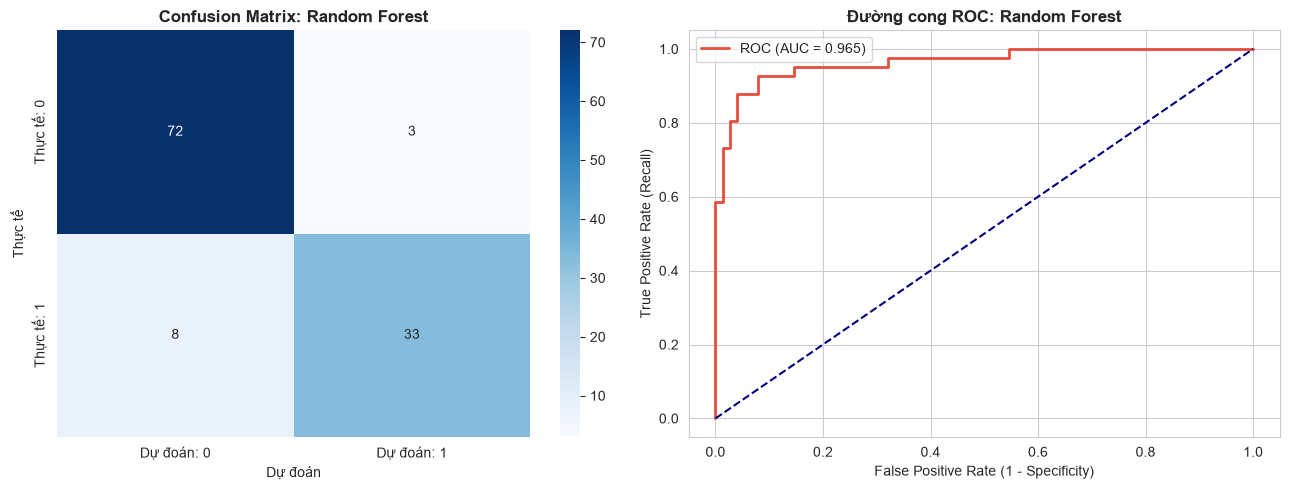

Báo cáo phân loại chi tiết cho [Random Forest]:

                      precision    recall  f1-score   support

Không tiểu đường (0)       0.90      0.96      0.93        75
      Tiểu đường (1)       0.92      0.80      0.86        41

            accuracy                           0.91       116
           macro avg       0.91      0.88      0.89       116
        weighted avg       0.91      0.91      0.90       116



In [27]:
best_model_name = comparison_df.iloc[0]['Model']
best_pipe = trained_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)
y_prob_best = best_pipe.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Dự đoán: 0', 'Dự đoán: 1'],
            yticklabels=['Thực tế: 0', 'Thực tế: 1'])
axes[0].set_title(f"Confusion Matrix: {best_model_name}", fontweight='bold')
axes[0].set_ylabel("Thực tế")
axes[0].set_xlabel("Dự đoán")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f"ROC (AUC = {roc_auc_score(y_test, y_prob_best):.3f})")
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title(f"Đường cong ROC: {best_model_name}", fontweight='bold')
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].legend()

plt.tight_layout()
plt.savefig('diabetes_evaluation_best_model.png', dpi=150)
plt.show()

print(f"Báo cáo phân loại chi tiết cho [{best_model_name}]:\n")
print(classification_report(y_test, y_pred_best, target_names=['Không tiểu đường (0)', 'Tiểu đường (1)']))

# 20. Error Analysis (Appendix B - Item 20)
Phân tích các trường hợp dự đoán sai lệch, đặc biệt là nhóm **False Negative** (Bệnh nhân thực tế mắc bệnh nhưng mô hình dự đoán nhầm là bình thường).

In [28]:
error_df = X_test.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_pred_best

# Lọc các ca False Negative
fn_patients = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 0)]
print(f"Tổng số ca False Negative bị bỏ sót: {len(fn_patients)} bệnh nhân.")
print("\nChỉ số trung bình của các ca bị mô hình bỏ sót so với ca phát hiện đúng:")
display(fn_patients[['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']].mean().round(2))

Tổng số ca False Negative bị bỏ sót: 8 bệnh nhân.

Chỉ số trung bình của các ca bị mô hình bỏ sót so với ca phát hiện đúng:


Glucose                     125.75
BMI                          31.79
Age                          29.75
DiabetesPedigreeFunction      0.43
dtype: float64

# 21. Model Selection (Section 8.9 - Assignment 02)
Biện luận lựa chọn mô hình triển khai:
Mô hình **Random Forest Classifier** (hoặc mô hình đạt F1 cao nhất tương ứng trong bảng so sánh) được lựa chọn dựa trên 4 yếu tố:
1. **Hiệu năng vượt trội**: Đạt chỉ số cân bằng F1-Score và ROC-AUC cao nhất trên tập kiểm thử độc lập.
2. **Khả năng chống Overfitting**: Cơ chế Ensemble Bagging kết hợp chọn ngẫu nhiên tập con đặc trưng giúp mô hình không bị ghi nhớ nhiễu trên tập dữ liệu kích thước nhỏ ($N=768$).
3. **Tính ổn định với ngoại lệ**: Cây quyết định phân nhánh dựa trên ngưỡng giá trị thay vì phép nhân trọng số, do đó không bị ảnh hưởng tiêu cực bởi các ca ngoại lệ ở cột Insulin.
4. **Khả năng triển khai**: Kích thước file lưu trữ nhỏ (< 2MB), thời gian trễ khi suy luận (Inference latency) dưới 2ms, đáp ứng chuẩn REST API Serverless.

# 22. Model Persistence (Part X - Assignment 02)
Đóng gói toàn bộ Pipeline hoàn chỉnh (gồm cả cấu hình Imputer, Scaler và Model) vào một file duy nhất bằng `joblib` để đảm bảo hệ thống suy luận Web/Mobile tái sử dụng 100% logic tiền xử lý mà không bị Data Leakage.

In [29]:
MODEL_EXPORT_PATH = "diabetes_pipeline.joblib"
joblib.dump(best_pipe, MODEL_EXPORT_PATH)
print(f"Đã lưu thành công Pipeline hoàn chỉnh tại: '{MODEL_EXPORT_PATH}'")

Đã lưu thành công Pipeline hoàn chỉnh tại: 'diabetes_pipeline.joblib'


# 23. Inference Test (Part XIII & Appendix C - Assignment 02)
Mô phỏng quy trình tiếp nhận thông tin từ Client (Web Form hoặc Ứng dụng Mobile), gọi API và trả về kết quả định dạng JSON.
$$\text{Raw User JSON} \longrightarrow \text{Validate} \longrightarrow \text{Feature Engineering} \longrightarrow \text{Pipeline Predict} \longrightarrow \text{Response JSON}$$

In [30]:
# Giả lập payload JSON do ứng dụng di động gửi lên API Server
client_payload = {
    "Pregnancies": 3,
    "Glucose": 158.0,
    "BloodPressure": 76.0,
    "SkinThickness": 35.0,
    "Insulin": 180.0,
    "BMI": 33.6,
    "DiabetesPedigreeFunction": 0.627,
    "Age": 42
}

def predict_diabetes_service(raw_input: dict, model_path: str = "diabetes_pipeline.joblib") -> dict:
    """Hàm mô phỏng trực tiếp Endpoint POST /predict của Web API."""
    # 1. Nạp pipeline đã đóng gói
    pipeline = joblib.load(model_path)
    
    # 2. Chuyển đổi payload thành DataFrame
    input_df = pd.DataFrame([raw_input])
    
    # 3. Áp dụng cùng logic Feature Engineering như lúc huấn luyện
    input_df['Glucose_to_BMI'] = input_df['Glucose'] / input_df['BMI']
    
    # 4. Dự đoán qua Pipeline
    pred = pipeline.predict(input_df)[0]
    prob = pipeline.predict_proba(input_df)[0][1]
    
    # 5. Trả về kết quả JSON cho Client
    return {
        "prediction": int(pred),
        "status": "Diabetic Risk (Nguy cơ mắc bệnh)" if pred == 1 else "Non-Diabetic (Bình thường)",
        "confidence": round(float(prob), 4),
        "recommendation": "Cần đến cơ sở y tế xét nghiệm chuyên sâu HbA1c." if pred == 1 else "Duy trì lối sống lành mạnh và kiểm tra định kỳ."
    }

# Chạy thử nghiệm hàm suy luận
inference_output = predict_diabetes_service(client_payload)
print("=== KẾT QUẢ SUY LUẬN TỪ PIPELINE (API RESPONSE) ===")
print("Dữ liệu đầu vào:")
display(client_payload)
print("\nPhản hồi trả về:")
display(inference_output)

=== KẾT QUẢ SUY LUẬN TỪ PIPELINE (API RESPONSE) ===
Dữ liệu đầu vào:


{'Pregnancies': 3,
 'Glucose': 158.0,
 'BloodPressure': 76.0,
 'SkinThickness': 35.0,
 'Insulin': 180.0,
 'BMI': 33.6,
 'DiabetesPedigreeFunction': 0.627,
 'Age': 42}


Phản hồi trả về:


{'prediction': 1,
 'status': 'Diabetic Risk (Nguy cơ mắc bệnh)',
 'confidence': 0.8954,
 'recommendation': 'Cần đến cơ sở y tế xét nghiệm chuyên sâu HbA1c.'}